# What is the THI *anomaly*, and why do we use it?

*A short, self-contained explainer.* THI (Temperature–Humidity Index) measures heat load. But when we
correlate **raw** THI with milk yield, heat appears to **increase** milk — which is biologically wrong.
This notebook shows why that happens and how the **THI anomaly** fixes it.

> **In one sentence.** The THI **anomaly** is *how much hotter or cooler a day was than the **typical**
> THI for that **same farm** in that **same calendar month**.
>
> $$\text{THI anomaly} \;=\; \text{THI on the day} \;-\; \overline{\text{THI}}\ \text{(for that farm, that month)}$$
>
> It answers **"was this day unusually hot?"** instead of **"is it summer?"** — and that distinction is
> the whole point, because milk and raw THI both rise in summer for reasons that have nothing to do with
> heat. Subtracting the farm–month normal removes that seasonal illusion and reveals the true
> (negative) effect of heat on milk.

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

df = pd.read_csv('../../Thesis_Data/Final_Data/Final_Merged_Data.csv',
                 usecols=['Farm_Code', 'Animal_ID', 'dtt', 'milk_kg', 'THI_1_avg'])
df['dtt']   = pd.to_datetime(df['dtt'], errors='coerce')
df['month'] = df['dtt'].dt.month
df['farm']  = df['Farm_Code'].astype(str)
df = df.dropna(subset=['milk_kg', 'THI_1_avg', 'month'])
print(f'{len(df):,} test-day records | {df.farm.nunique()} farms | THI ranges {df.THI_1_avg.min():.0f}-{df.THI_1_avg.max():.0f}')

1,631,410 test-day records | 316 farms | THI ranges 29-81


## 1. The puzzle — raw THI says heat *increases* milk

If we simply correlate raw THI with milk yield across all records, we get a **positive** number. Taken
at face value, that says *hotter days = more milk* — the opposite of heat stress.

In [ ]:
r_raw = df['THI_1_avg'].corr(df['milk_kg'])
print(f'correlation( raw THI , milk_kg ) = {r_raw:+.3f}')
print('Positive -> heat appears to HELP milk. That cannot be right. Something is wrong with the question.')

correlation( raw THI , milk_kg ) = +0.061
Positive -> heat appears to HELP milk. That cannot be right. Something is wrong with the question.


## 2. Why the raw number lies — the *season confound*

The classic trap: **two things that both follow the seasons look related to each other, even when
neither causes the other.** (Ice-cream sales and drownings both peak in summer — ice cream doesn't
cause drowning; summer causes both.)

Here, **summer raises milk for non-heat reasons** — the calving cycle, fresh feed, longer daylight —
*and* summer raises THI. So high-THI days are mostly summer days, and summer days happen to be
high-milk days. The raw correlation is really measuring **"is it summer?"**, not "is it hot?".

The plot below makes it obvious: milk and THI **rise and fall together across the calendar year.**

Both curves peak Jun-Aug together. That shared seasonal shape is the confound.


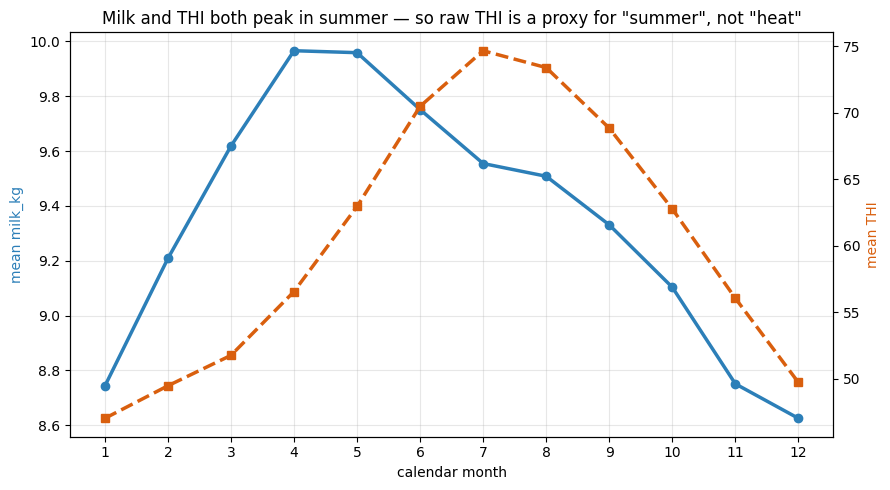

In [ ]:
mo = df.groupby('month').agg(milk=('milk_kg', 'mean'), THI=('THI_1_avg', 'mean'))
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mo.index, mo['milk'], 'o-', color='#2c7fb8', lw=2.5, label='mean milk_kg')
ax.set_xlabel('calendar month'); ax.set_ylabel('mean milk_kg', color='#2c7fb8')
ax.set_xticks(range(1, 13))
ax2 = ax.twinx()
ax2.plot(mo.index, mo['THI'], 's--', color='#d95f0e', lw=2.5, label='mean THI')
ax2.set_ylabel('mean THI', color='#d95f0e')
ax.set_title('Milk and THI both peak in summer — so raw THI is a proxy for "summer", not "heat"')
ax.grid(alpha=.3); fig.tight_layout(); plt.show()
print('Both curves peak Jun-Aug together. That shared seasonal shape is the confound.')

## 3. The idea — compare each day to what is *normal* for that farm & month

We do not actually care whether a day is hot *in absolute terms* (that just tells us the season). We
care whether a day was **hotter than usual** — because *that* is the excess heat an animal experiences.

So for every farm and every calendar month, we compute the **normal** (average) THI, and then subtract
it:

- A July day at THI 78 on a farm whose **July normal is 78** → anomaly **0** (a completely ordinary
  July day — no excess heat).
- A July day at THI 84 on that same farm → anomaly **+6** (genuinely hotter than normal).
- A January day at THI 55 where the **January normal is 50** → anomaly **+5** (unusually warm winter
  day — also "excess heat", even though 55 is a low absolute THI).

The anomaly is **farm-specific** (a northern farm is compared to its own cooler normal) and
**month-specific** (July is compared to July), so it strips out both geography and season.

In [ ]:
# The whole calculation is one line: subtract the farm-month mean from each record's THI.
df['THI_farm_month_normal'] = df.groupby(['farm', 'month'])['THI_1_avg'].transform('mean')
df['THI_anomaly']           = df['THI_1_avg'] - df['THI_farm_month_normal']
print('THI_anomaly = THI_1_avg  -  mean(THI_1_avg | same farm, same month)')
print(df[['THI_anomaly']].describe().round(2).T.to_string())
print('\nNote: the anomaly is centred on 0 (by construction) and roughly symmetric -> it is pure')
print('"hotter/cooler than normal", with the seasonal level removed.')

THI_anomaly = THI_1_avg  -  mean(THI_1_avg | same farm, same month)
                 count  mean   std    min   25%   50%   75%    max
THI_anomaly  1631410.0   0.0  3.29 -15.86 -2.19  0.06  2.27  13.21

Note: the anomaly is centred on 0 (by construction) and roughly symmetric -> it is pure
"hotter/cooler than normal", with the seasonal level removed.


## 4. A worked example — one farm, one July

Pick a single well-sampled farm and look at its July. Each test-day's anomaly is just its THI minus
that farm's July average.

In [ ]:
# choose a farm with plenty of July records, for a clean example
jul = df[df.month == 7]
farm_ex = jul.farm.value_counts().index[0]
sub = jul[jul.farm == farm_ex].copy()
normal = sub['THI_1_avg'].mean()
print(f'Farm {farm_ex}, July:  normal (average) THI = {normal:.1f}\n')
ex = (sub.sort_values('THI_1_avg')
        .iloc[np.linspace(0, len(sub)-1, 8).astype(int)]
        [['dtt', 'THI_1_avg', 'THI_farm_month_normal', 'THI_anomaly']]
        .rename(columns={'dtt': 'date', 'THI_1_avg': 'THI_that_day',
                         'THI_farm_month_normal': 'farm_July_normal', 'THI_anomaly': 'anomaly'}))
ex['date'] = ex['date'].dt.date
print(ex.round(2).to_string(index=False))
print('\nRead: anomaly < 0 = cooler-than-normal July day ; anomaly > 0 = hotter-than-normal July day.')

Farm 5700539, July:  normal (average) THI = 75.1

      date  THI_that_day  farm_July_normal  anomaly
2014-07-30         68.64             75.09    -6.44
2018-07-11         73.04             75.09    -2.04
2020-07-06         73.87             75.09    -1.22
2023-07-31         76.53             75.09     1.45
2023-07-31         76.53             75.09     1.45
2022-07-29         76.70             75.09     1.61
2021-07-06         76.74             75.09     1.65
2015-07-14         78.04             75.09     2.95

Read: anomaly < 0 = cooler-than-normal July day ; anomaly > 0 = hotter-than-normal July day.


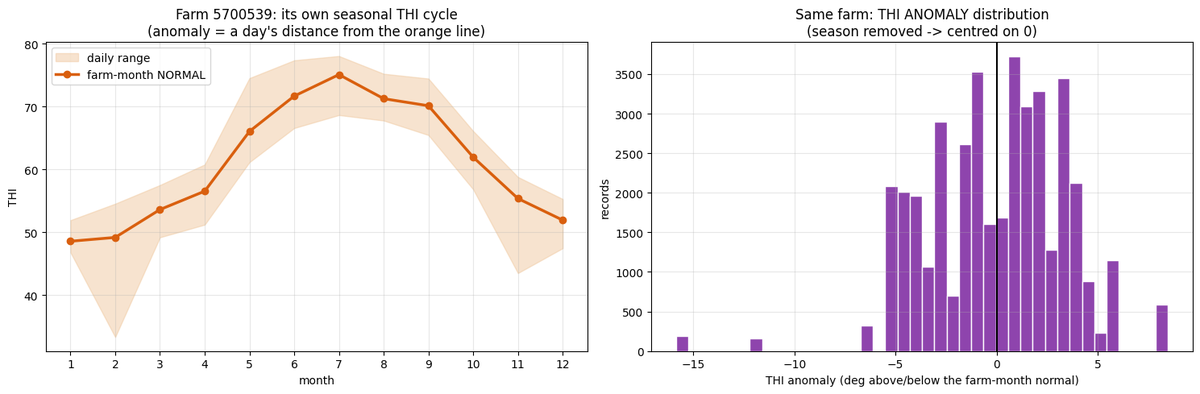

In [ ]:
# Visualise the anomaly as "distance from the farm's own seasonal normal line".
g = df[df.farm == farm_ex].groupby('month').agg(THI=('THI_1_avg', 'mean'),
                                                lo=('THI_1_avg', 'min'), hi=('THI_1_avg', 'max'))
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# left: the farm's seasonal THI cycle = the "normal" line the anomaly is measured against
ax[0].fill_between(g.index, g['lo'], g['hi'], color='#f0c9a0', alpha=.5, label='daily range')
ax[0].plot(g.index, g['THI'], 'o-', color='#d95f0e', lw=2.5, label='farm-month NORMAL')
ax[0].set(title=f'Farm {farm_ex}: its own seasonal THI cycle\n(anomaly = a day\'s distance from the orange line)',
          xlabel='month', ylabel='THI'); ax[0].set_xticks(range(1, 13)); ax[0].legend(); ax[0].grid(alpha=.3)
# right: the anomaly distribution for that farm — centred on 0, no seasonal hump
ax[1].hist(df[df.farm == farm_ex]['THI_anomaly'], bins=40, color='#8e44ad', edgecolor='white')
ax[1].axvline(0, color='k', lw=1.5)
ax[1].set(title='Same farm: THI ANOMALY distribution\n(season removed -> centred on 0)',
          xlabel='THI anomaly (deg above/below the farm-month normal)', ylabel='records'); ax[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

## 5. Raw vs anomaly, side by side — the sign flips

Now the payoff. We compare the same relationship two ways:

- **Raw THI** (confounded by season): binned mean milk per THI level.
- **THI anomaly** (season removed): to also strip out *which animals* are on which farms, we use the
  **within-animal** deviation — each record compared to that animal's own average — so we are asking
  *"when THIS cow has a hotter-than-normal day, does SHE produce less?"*

RAW correlation      : +0.061   (positive - wrong)
ANOMALY within-animal: -0.061 kg per +10 THI-anomaly   (negative - correct biology)

Same data, same THI, same milk. Removing season flips the sign from "heat helps" to "heat hurts".


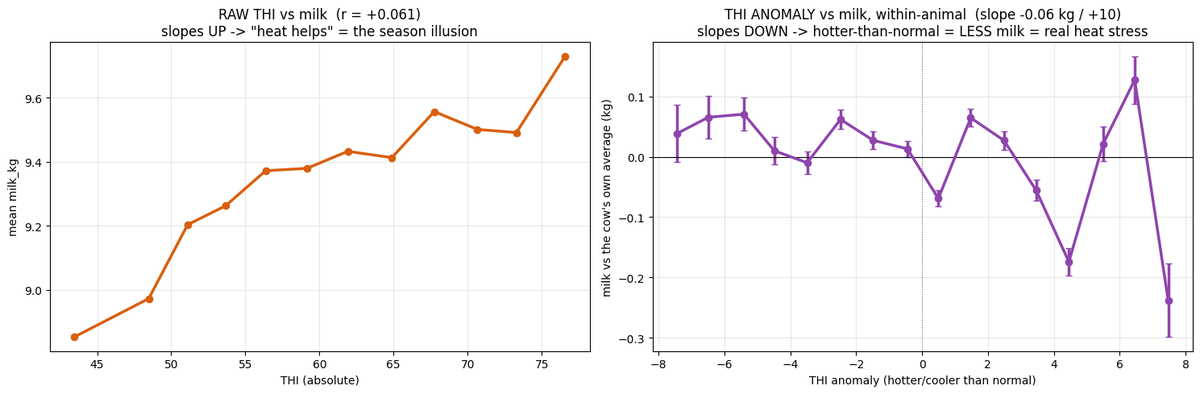

In [ ]:
# raw dose-response (confounded)
raw = df.copy(); raw['bin'] = pd.qcut(raw['THI_1_avg'], 12, duplicates='drop')
rawg = raw.groupby('bin', observed=True).agg(y=('milk_kg', 'mean'), x=('THI_1_avg', 'mean'))

# anomaly dose-response, WITHIN animal (removes season AND between-animal differences)
df['milk_wa'] = df['milk_kg'] - df.groupby('Animal_ID')['milk_kg'].transform('mean')
a = df.dropna(subset=['THI_anomaly', 'milk_wa']).copy()
a['bin'] = pd.cut(a['THI_anomaly'], np.arange(-8, 9, 1.0))
ag = a.groupby('bin', observed=True).agg(y=('milk_wa', 'mean'),
        sem=('milk_wa', lambda s: s.std()/np.sqrt(len(s))), x=('THI_anomaly', 'mean'), n=('milk_wa', 'size'))
ag = ag[ag['n'] > 500]
slope = np.polyfit(a['THI_anomaly'], a['milk_wa'], 1)[0]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(rawg['x'], rawg['y'], 'o-', color='#d95f0e', lw=2.5)
ax[0].set(title=f'RAW THI vs milk  (r = {df["THI_1_avg"].corr(df["milk_kg"]):+.3f})\n'
                'slopes UP -> "heat helps" = the season illusion',
          xlabel='THI (absolute)', ylabel='mean milk_kg'); ax[0].grid(alpha=.3)
ax[1].errorbar(ag['x'], ag['y'], yerr=1.96*ag['sem'], fmt='o-', color='#8e44ad', lw=2.5, capsize=3)
ax[1].axhline(0, color='k', lw=.8); ax[1].axvline(0, color='gray', ls=':', lw=.8)
ax[1].set(title=f'THI ANOMALY vs milk, within-animal  (slope {slope*10:+.2f} kg / +10)\n'
                'slopes DOWN -> hotter-than-normal = LESS milk = real heat stress',
          xlabel='THI anomaly (hotter/cooler than normal)', ylabel='milk vs the cow\'s own average (kg)'); ax[1].grid(alpha=.3)
fig.tight_layout(); plt.show()
print(f'RAW correlation      : {df["THI_1_avg"].corr(df["milk_kg"]):+.3f}   (positive - wrong)')
print(f'ANOMALY within-animal: {slope*10:+.3f} kg per +10 THI-anomaly   (negative - correct biology)')
print('\nSame data, same THI, same milk. Removing season flips the sign from "heat helps" to "heat hurts".')

## 6. Why we use it — and its one honest limitation

**Why the anomaly is the right factor**
- **Removes the season confound** — the reason the raw correlation had the wrong sign.
- **Farm-specific** — a cool northern farm is judged against its own normal, not Campania's, so
  geography can't sneak in.
- **Month-specific** — July is compared to July; the calendar cycle is gone.
- **Interpretable** — "+6" means "6 THI units hotter than this place normally is at this time of year",
  i.e. exactly the *excess* heat an animal actually experiences.
- **Matches the causal question** — we want the effect of *unusual heat*, not the effect of *being summer*.

**The one limitation to state honestly.** Because the anomaly is defined *within* each farm-month, it
removes the seasonal **level**. So it measures **acute** heat (a hotter-than-normal day) and **cannot**
test **chronic** seasonal heat — e.g. whether simply *being in summer at all*, versus the buffalo's
thermal-comfort zone, depresses production. That chronic question is inseparable from feeding, calving
and daylight, so no purely statistical adjustment can isolate it from this data. The anomaly answers
the acute question cleanly; the chronic one needs a controlled/experimental design.

---
**Bottom line for the discussion.** *Raw THI conflates heat with the calendar. The THI anomaly —
each day minus its farm-and-month normal — isolates genuine excess heat, and only then does the
expected biology appear: hotter-than-normal days reduce milk yield.*